# STAMP — MIPAR Image-Level Measurement Analysis

Loads per-FOV image-level measurements from MIPAR batch CSV exports using
`stamp.io.load_mipar_image` and compares key 2-D stereological quantities
across three material states.

**Contents**
1. Load all three material states
2. Inspect the tidy DataFrame
3. 2-D summary tables — phase fraction, particle size, interparticle spacing
4. 2-D box plots per phase (Nature journal style)

> **Note:** 3-D stereological quantities (surface area density $S_V$,
> caliper diameter $\bar{D}$, 3-D mean free path $\lambda_{3D}$,
> interparticle spacing $\lambda$) will be added once
> `stamp.stereo` image-level functions are implemented.

In [1]:
%matplotlib inline
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from stamp.io import load_mipar_image
from stamp.export import journal_style, save, to_csv, to_latex, NATURE

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("notebooks/data") if Path.cwd().name != "notebooks" else Path("data")
OUT_DIR = DATA_DIR / "GOO220_image"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "GOO220_51": DATA_DIR / "GOO220_51_BatchMeas.csv",
    "GOO220_52": DATA_DIR / "GOO220_52_BatchMeas.csv",
    "GOO220_53": DATA_DIR / "GOO220_53_BatchMeas.csv",
}
PHASES = ["M23C6", "MX ZPhase", "Laves"]

## 1. Load all three material states

Each file contains one row per FOV.  `load_mipar_image` melts the wide-format
table to long format — one row per (FOV × phase) combination.

In [2]:
frames = []
for state, path in FILES.items():
    df = load_mipar_image(path)
    df.insert(0, "State", state)
    frames.append(df)
    n_fovs = df["Image"].nunique()
    print(f"{state}: {n_fovs} FOVs × {df['Phase'].nunique()} phases → {len(df)} rows")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nCombined: {len(df_all)} rows total")

GOO220_51: 10 FOVs × 3 phases → 30 rows
GOO220_52: 10 FOVs × 3 phases → 30 rows
GOO220_53: 10 FOVs × 3 phases → 30 rows

Combined: 90 rows total


## 2. Inspect the tidy DataFrame

In [3]:
display(df_all.head(12))
print("\nColumns:", df_all.columns.tolist())
print("\nDtypes:")
print(df_all.dtypes)
print("\nMissing values per column:")
print(df_all.isna().sum())

,State,Image,Phase,Area Fraction (%),Number Density (features/um^2),Mean Intercept - Objects (Random) (um),Mean Intercept - Holes (Random) (um),Mean Inverse Intercept - Objects (Random) (1/um),Mean Inverse Intercept - Holes (Random) (1/um),Mode Intercept - Objects (Random) (um),Mode Intercept - Holes (Random) (um),Mode Inverse Intercept - Objects (Random) (1/um),Mode Inverse Intercept - Holes (Random) (1/um),ASTM Grain Size Number (Random Lines),Total Line Length (Random) (um),Total Intersections (Random)
0,GOO220_51,T3_Mode2-GOO220_51_001_processed.tif,M23C6,4.2380,2.298863,0.124164,2.064268,16.219445,3.958052,0.090,0.25,7.5,1.5,22.7,14865.119264,10821.0
1,GOO220_51,T3_Mode2-GOO220_51_002_processed.tif,M23C6,4.2680,2.701428,0.115301,1.986533,16.295784,3.926539,0.070,0.25,7.5,1.5,22.9,15031.367810,12012.0
2,GOO220_51,T3_Mode2-GOO220_51_003_processed.tif,M23C6,4.6430,2.461301,0.122981,2.044001,15.311132,4.124997,0.090,0.25,7.5,1.5,22.7,15017.664835,12095.0
3,GOO220_51,T3_Mode2-GOO220_51_004_processed.tif,M23C6,4.6130,2.870930,0.107681,1.843055,16.859730,3.592934,0.065,0.15,7.5,1.0,23.1,14863.657674,13107.0
4,GOO220_51,T3_Mode2-GOO220_51_006_processed.tif,M23C6,4.3210,2.496614,0.119591,1.949551,15.853284,4.266697,0.070,0.25,7.5,1.5,22.8,14995.312318,11962.0
5,GOO220_51,T3_Mode2-GOO220_51_007_processed.tif,M23C6,4.3910,1.687951,0.153761,2.217819,14.628816,4.384631,0.075,0.25,4.5,1.5,22.0,14867.017846,9602.0
6,GOO220_51,T3_Mode2-GOO220_51_008_processed.tif,M23C6,4.5600,2.305925,0.126003,1.885006,14.938392,4.202561,0.090,0.25,7.5,1.5,22.6,15257.991307,11858.0
7,GOO220_51,T3_Mode2-GOO220_51_009_processed.tif,M23C6,4.5610,2.517802,0.118982,2.053246,15.691875,3.986356,0.090,0.25,7.5,1.5,22.8,15205.942381,12317.0
8,GOO220_51,T3_Mode2-GOO220_51_010_processed.tif,M23C6,4.6570,2.309456,0.126259,2.064394,15.096630,3.816931,0.090,0.25,7.5,1.5,22.6,15166.170304,11888.0
9,GOO220_51,T3_Mode2-GOO220_51_011_processed.tif,M23C6,4.5790,2.493083,0.122618,1.974197,15.407571,3.983106,0.090,0.25,7.5,1.5,22.7,15001.290927,11899.0



Columns: ['State', 'Image', 'Phase', 'Area Fraction (%)', 'Number Density (features/um^2)', 'Mean Intercept - Objects (Random) (um)', 'Mean Intercept - Holes (Random) (um)', 'Mean Inverse Intercept - Objects (Random) (1/um)', 'Mean Inverse Intercept - Holes (Random) (1/um)', 'Mode Intercept - Objects (Random) (um)', 'Mode Intercept - Holes (Random) (um)', 'Mode Inverse Intercept - Objects (Random) (1/um)', 'Mode Inverse Intercept - Holes (Random) (1/um)', 'ASTM Grain Size Number (Random Lines)', 'Total Line Length (Random) (um)', 'Total Intersections (Random)']

Dtypes:
State                                                   str
Image                                                   str
Phase                                                   str
Area Fraction (%)                                   float64
Number Density (features/um^2)                      float64
Mean Intercept - Objects (Random) (um)              float64
Mean Intercept - Holes (Random) (um)                float64
Me

## 3. 2-D summary tables

Mean and standard deviation across FOVs for the three key 2-D quantities —
total phase fraction, mean particle size, and 2-D interparticle spacing —
grouped by material state and phase.  Exported as CSV and LaTeX.

In [4]:
# 2-D quantities of interest
PLOT_COLS_2D = {
    "Area Fraction (%)":                       "Phase fraction (%)",
    "Mean Intercept - Objects (Random) (um)":  "Mean particle size — 2D (µm)",
    "Mean Intercept - Holes (Random) (um)":    "Interparticle spacing — 2D (µm)",
}

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]
    summary = (
        sub.groupby("State")[list(PLOT_COLS_2D.keys())]
        .agg(["mean", "std"])
        .round(4)
    )
    summary.columns = [f"{PLOT_COLS_2D[m]} ({stat})" for m, stat in summary.columns]
    summary = summary.reset_index()

    print(f"\n── {phase} ──")
    display(summary)

    slug = phase.replace(" ", "_")
    to_csv(summary, OUT_DIR / f"summary_2d_{slug}.csv", decimals=4)
    to_latex(
        summary,
        OUT_DIR / f"summary_2d_{slug}.tex",
        caption=f"2-D per-FOV measurement summary — {phase}.",
        label=f"tab:summary-2d-{slug.lower()}",
        decimals=4,
    )
    print(f"  Saved → {OUT_DIR / f'summary_2d_{slug}.csv'}")


── M23C6 ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,4.4831,0.1616,0.1237,0.0119,2.0082,0.1060
1,GOO220_52,3.4739,0.3689,0.0898,0.0105,1.8354,0.0941
2,GOO220_53,4.9770,0.3472,0.1313,0.0170,1.9709,0.2365


  Saved → data\GOO220_image\summary_2d_M23C6.csv

── MX ZPhase ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,0.4704,0.1073,0.0767,0.0069,4.4292,0.4123
1,GOO220_52,0.2378,0.0466,0.0517,0.0079,4.8863,0.2726
2,GOO220_53,0.3716,0.0675,0.0674,0.0085,4.4807,0.3951


  Saved → data\GOO220_image\summary_2d_MX_ZPhase.csv

── Laves ──


,State,Phase fraction (%) (mean),Phase fraction (%) (std),Mean particle size — 2D (µm) (mean),Mean particle size — 2D (µm) (std),Interparticle spacing — 2D (µm) (mean),Interparticle spacing — 2D (µm) (std)
0,GOO220_51,0.6679,0.2704,0.3125,0.0500,2.8686,0.7760
1,GOO220_52,0.5757,0.2735,0.2711,0.0204,3.0596,0.8691
2,GOO220_53,0.4257,0.1433,0.2850,0.0384,3.4769,1.4028


  Saved → data\GOO220_image\summary_2d_Laves.csv


## 4. 2-D box plots per phase

For each phase: three panels comparing the three material states —
phase fraction, mean particle size (2-D), and interparticle spacing (2-D).
Rendered in Nature journal style.

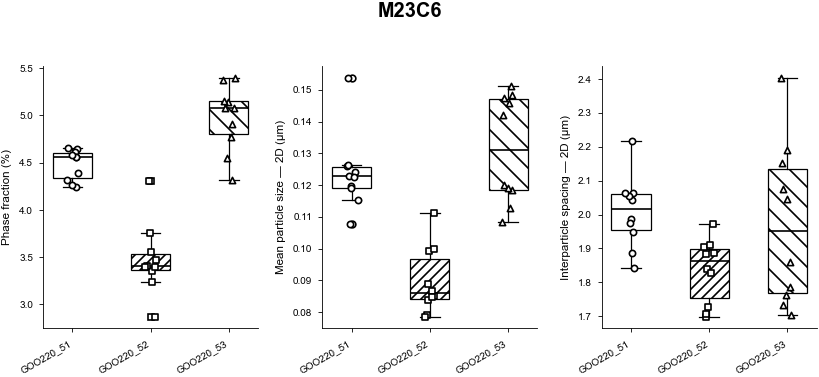

Saved M23C6 → data\GOO220_image


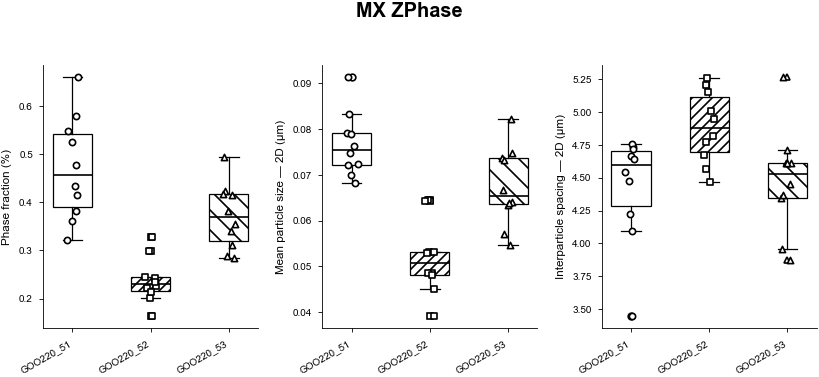

Saved MX ZPhase → data\GOO220_image


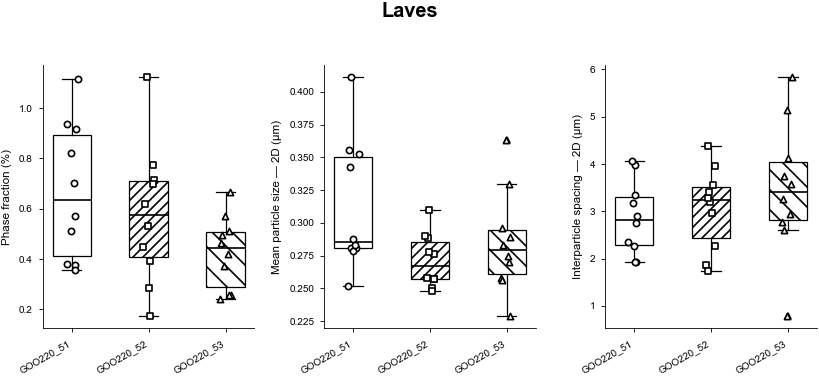

Saved Laves → data\GOO220_image


In [5]:
_BW_HATCHES = ["", "////", "\\\\"]
_BW_MARKERS = ["o", "s", "^"]
STATES = list(FILES.keys())

for phase in PHASES:
    sub = df_all[df_all["Phase"] == phase]

    with journal_style(NATURE):
        fig, axes = plt.subplots(
            1, len(PLOT_COLS_2D),
            figsize=(180 / 25.4, 180 / 25.4 * 0.45),
            sharey=False,
        )
        rng = np.random.default_rng(42)

        for ax, (col, label) in zip(axes, PLOT_COLS_2D.items()):
            for i, state in enumerate(STATES):
                vals = sub[sub["State"] == state][col].dropna().values
                if len(vals) == 0:
                    continue
                ax.boxplot(
                    vals,
                    positions=[i + 1],
                    widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i], linewidth=0.75),
                    medianprops=dict(color="black", linewidth=1.0),
                    whiskerprops=dict(color="black", linewidth=0.75),
                    capprops=dict(color="black", linewidth=0.75),
                    flierprops=dict(marker=_BW_MARKERS[i], markerfacecolor="white",
                                   markeredgecolor="black", markersize=4),
                    manage_ticks=False,
                )
                jitter = rng.uniform(-0.08, 0.08, len(vals))
                ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i],
                           facecolors="white", edgecolors="black", s=14, zorder=3)

            ax.set_xticks(range(1, len(STATES) + 1))
            ax.set_xticklabels(STATES, rotation=30, ha="right")
            ax.set_ylabel(label)

        fig.suptitle(f"{phase}", fontweight="bold", y=1.02)
        fig.tight_layout()
        slug = phase.replace(" ", "_")
        save(fig, OUT_DIR / f"boxplot_2d_{slug}", formats=["pdf", "png"])
        plt.show()
        print(f"Saved {phase} → {OUT_DIR}")

## Next steps

The stereological quantities derivable from these image-level measurements —
volume fraction $V_V$, surface area density $S_V$, caliper diameter $\bar{D}$,
2-D and 3-D mean free path $\lambda$, and interparticle spacing — will be
added in the next notebook once `stamp.stereo` image-level functions are
implemented (see spec `specs/stereo-image-quantities.md`).